### 1) Setup & imports

In [28]:
# === setup & imports ===
import os, ast, random
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from config import *
from models.flow_forward import FlowForwardModel
from utils.data_utils.load_data import load_dataset  # returns (P_all, S_all, C_tensor) as torch tensors

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


### 2) Load stats (for normalization/denormalization)

In [29]:
# === load normalization stats ===
S_mean = torch.tensor(np.load("data/S_mean.npy"), dtype=torch.float32, device=device)
S_std  = torch.tensor(np.load("data/S_std.npy"),  dtype=torch.float32, device=device)
P_mean = torch.tensor(np.load("data/P_mean.npy"), dtype=torch.float32, device=device)
P_std  = torch.tensor(np.load("data/P_std.npy"),  dtype=torch.float32, device=device)

def norm_S(S):    return (S - S_mean) / torch.clamp(S_std, min=1e-12)
def norm_P(P):    return (P - P_mean) / torch.clamp(P_std, min=1e-12)
def denorm_P(Pn): return Pn * P_std + P_mean
def adjust_sigma_by_rho(sigma_raw: torch.Tensor,
                        S_raw: torch.Tensor,
                        rho_min: float = 0.3,
                        rho_max: float = 1.0,
                        eps: float = 1e-12) -> torch.Tensor:
    """
    Linearly scale predicted std so that:
      - at rho = rho_max (default 1.0), std = 0
      - at rho = rho_min (default 0.3), std = original sigma_raw
      - clamp outside [rho_min, rho_max] to [1, 0] respectively.

    Args:
        sigma_raw: (..., P_dim) std in RAW P space (after denorm)
        S_raw:     (..., S_dim) *raw* S (not normalized); S[..., 3] is rho
    Returns:
        sigma_adj: (..., P_dim) adjusted std
    """
    rho = S_raw[..., 3]
    scale = (rho_max - rho) / max(eps, (rho_max - rho_min))  # 1 at rho_min -> 0 at rho_max
    scale = torch.clamp(scale, 0.0, 1.0)
    # match dims for broadcasting over P_dim
    while scale.dim() < sigma_raw.dim():
        scale = scale.unsqueeze(-1)
    return sigma_raw * scale


print("✅ Loaded S & P normalization stats")


✅ Loaded S & P normalization stats


### 3) Load model checkpoint

In [30]:
# === load model checkpoint & config ===
trial = 2
flow_type = "realnvp"       # "planar" | "maf" | "realnvp"

save_dir    = f"checkpoints/flow/{flow_type}/{flow_type}_trial_{trial}"
ckpt_path   = f"{save_dir}/{flow_type}_ckpt_{trial}.pt"
config_path = f"{save_dir}/config_{trial}.txt"

# === load config file into a dict ===
config_dict = {}
with open(config_path, "r") as f:
    for line in f:
        if ":" in line:
            key, val = line.strip().split(":", 1)
            key, val = key.strip(), val.strip()
            try:
                config_dict[key] = ast.literal_eval(val)
            except Exception:
                config_dict[key] = val

print("✅ Loaded config:")
for k, v in config_dict.items():
    print(f"   - {k}: {v}")

# === rebuild model using config values ===
S_DIM       = config_dict.get("S_DIM", 4)
P_DIM       = config_dict.get("P_DIM", 9)
HIDDEN_DIMS = config_dict.get("HIDDEN_DIMS", [128, 64, 32])
NUM_FLOWS   = config_dict.get("NUM_FLOWS", 6)

model = FlowForwardModel(S_dim=S_DIM, P_dim=P_DIM, hidden_dims=HIDDEN_DIMS, num_flows=NUM_FLOWS, flow_type=flow_type).to(device)
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state)
model.eval()

print(f"\n✅ Loaded FlowForwardModel from trial {trial}")

✅ Loaded config:
   - S_DIM: 4
   - P_DIM: 9
   - HIDDEN_DIMS: [256, 128, 64, 32, 16]
   - NUM_FLOWS: 6
   - FLOW_TYPE: realnvp
   - BATCH_SIZE: 32
   - LEARNING_RATE: 0.0005
   - NUM_EPOCHS: 400
   - SIGMA_MIN: 0.001

✅ Loaded FlowForwardModel from trial 2


/var/folders/9z/9fdpt4_148s8zzl9h0tr9dgw0000gn/T/ipykernel_60649/3367198350.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=d

### 4) Load the distributional dataset and group by S

In [31]:
# === load the distributional dataset and group by S ===
P_all, S_all, _ = load_dataset(DISTRIBUTIONAL_DATA_PATH)

S_np = np.round(S_all.numpy(), 6)
P_np = P_all.numpy()

# group by unique S (as tuples for dict keys)
keys, inverse = np.unique(S_np, axis=0, return_inverse=True)
empirical_data = { tuple(k.tolist()): P_np[inverse == i] for i, k in enumerate(keys) }

S_keys = list(empirical_data.keys())
print(f"✅ Grouped {len(S_keys)} unique S values from distributional dataset.")

✅ Grouped 30 unique S values from distributional dataset.


### 5) Pick one S, predict μ/σ, sample P (then denormalize)

In [32]:
# === helpers for flow evaluation ===
@torch.no_grad()
def get_mu_sigma_for_S(model, Sn: torch.Tensor):
    """
    Compute μ(S), σ(S) produced by the conditioner MLP inside the flow model,
    in the (normalized P) space.
    Sn: (B, S_dim) normalized S
    Returns: mu_n (B, P_dim), sigma_n (B, P_dim)
    """
    h = model.mlp(Sn)
    mu_n = model.mu_layer(h)
    log_sigma_n = model.log_sigma_layer(h)
    sigma_n = torch.exp(log_sigma_n)
    return mu_n, sigma_n

@torch.no_grad()
def get_mu_sigma_raw_for_S(model, Sn: torch.Tensor):
    h = model.mlp(Sn)
    mu_n = model.mu_layer(h)
    log_sigma_n = model.log_sigma_layer(h)
    sigma_n = torch.exp(log_sigma_n)
    # denorm to RAW space
    mu_raw = denorm_P(mu_n)
    sigma_raw = sigma_n * P_std
    return mu_raw, sigma_raw


@torch.no_grad()
def sample_P_from_flow(model, Sn: torch.Tensor, num_samples=500):
    """
    Sample P ~ p(P|S) from the FLOW model in normalized space, then return denormalized samples.
    Sn: (B, S_dim) normalized S
    Returns: P_hat (B, num_samples, P_dim) in RAW space
    """
    Pn_samples = model.sample(Sn, num_samples=num_samples)       # normalized P
    P_samples  = denorm_P(Pn_samples)                            # back to raw
    return P_samples


@torch.no_grad()
def sample_P_from_flow_with_rho_shrink(model, Sn: torch.Tensor, S_raw: torch.Tensor,
                                       num_samples=500, eps=1e-12):
    """
    Sample P ~ p(P|S) in normalized space, denorm to RAW, then linearly
    contract deviations from μ(S) by the rho scale so that rho=1 -> collapse.
    """
    # normal samples (normalized P)
    Pn_samples = model.sample(Sn, num_samples=num_samples)         # (B, N, P)
    P_samples  = denorm_P(Pn_samples)                              # RAW (B, N, P)

    # conditioner μ in RAW space
    h = model.mlp(Sn)
    mu_n = model.mu_layer(h)                                       # (B, P)
    mu_raw = denorm_P(mu_n)                                        # (B, P)

    # rho-based scale in [0,1]
    rho = S_raw[..., 3]                                            # (B,)
    scale = (1.0 - rho) / max(eps, (1.0 - 0.3))                    # 1 at 0.3 -> 0 at 1.0
    scale = torch.clamp(scale, 0.0, 1.0).unsqueeze(-1).unsqueeze(-1)  # (B,1,1)

    # contract samples toward μ
    P_adj = mu_raw.unsqueeze(1) + scale * (P_samples - mu_raw.unsqueeze(1))  # (B,N,P)
    return P_adj


@torch.no_grad()
def flow_logprob_batch(model, Sn: torch.Tensor, P_raw: torch.Tensor):
    """
    Exact log p(P|S) under the trained flow (per-sample).
    Inputs on device. P_raw is raw; we will normalize to match training space.
    Returns: log_prob (B,) for the batch.
    """
    Pn = norm_P(P_raw)
    z_k, logdet_total, _, _ = model(Sn, Pn)                      # forward through flow
    # base is standard Normal in z_k
    LOG_2PI = np.log(2.0 * np.pi)
    log_p0 = -0.5 * (z_k**2 + LOG_2PI).sum(dim=1)                # (B,)
    return log_p0 + logdet_total                                 # (B,)

In [ ]:
# === pick one S, sample from model, compare to empirical ===
idx = 1 
S_val = np.array(S_keys[idx], dtype=float)
P_true_samples = empirical_data[tuple(S_val.tolist())]

print(f"✅ S[{idx}] =", S_val, "| Empirical P shape:", P_true_samples.shape)

S_val_t = torch.tensor(S_val, dtype=torch.float32, device=device).unsqueeze(0)
Sn = norm_S(S_val_t)

mu_n, sigma_n = get_mu_sigma_for_S(model, Sn)
P_hat = sample_P_from_flow_with_rho_shrink(model, Sn, S_val_t, num_samples=100)
P_hat_np = P_hat[0].cpu().numpy()


mu_hat = denorm_P(mu_n[0])
sigma_hat = sigma_n[0] * P_std
mu_hat_np = mu_hat.cpu().numpy()
sigma_hat_adj = adjust_sigma_by_rho(sigma_hat, S_val_t)
sigma_hat_np  = sigma_hat.cpu().numpy()
sigma_hat_adj_np = sigma_hat_adj.cpu().numpy()

print("✅ Got predicted μ and σ (denormalized). Samples:", P_hat_np.shape)

print("σ (raw, before adj):", np.round(sigma_hat_np, 6))
print("σ (raw, after  adj):", np.round(sigma_hat_adj_np, 6))

✅ S[1] = [29.58639908  0.          0.          0.48135599] | Empirical P shape: (100, 9)
✅ Got predicted μ and σ (denormalized). Samples: (100, 9)
σ (raw, before adj): [0.003288 0.002236 0.001686 0.003415 0.001918 0.002907 0.001456 0.000831
 0.001432]
σ (raw, after  adj): [0.002436 0.001656 0.001249 0.00253  0.001421 0.002154 0.001079 0.000615
 0.001061]


### 6) Plots: histograms (pred vs empirical) per component

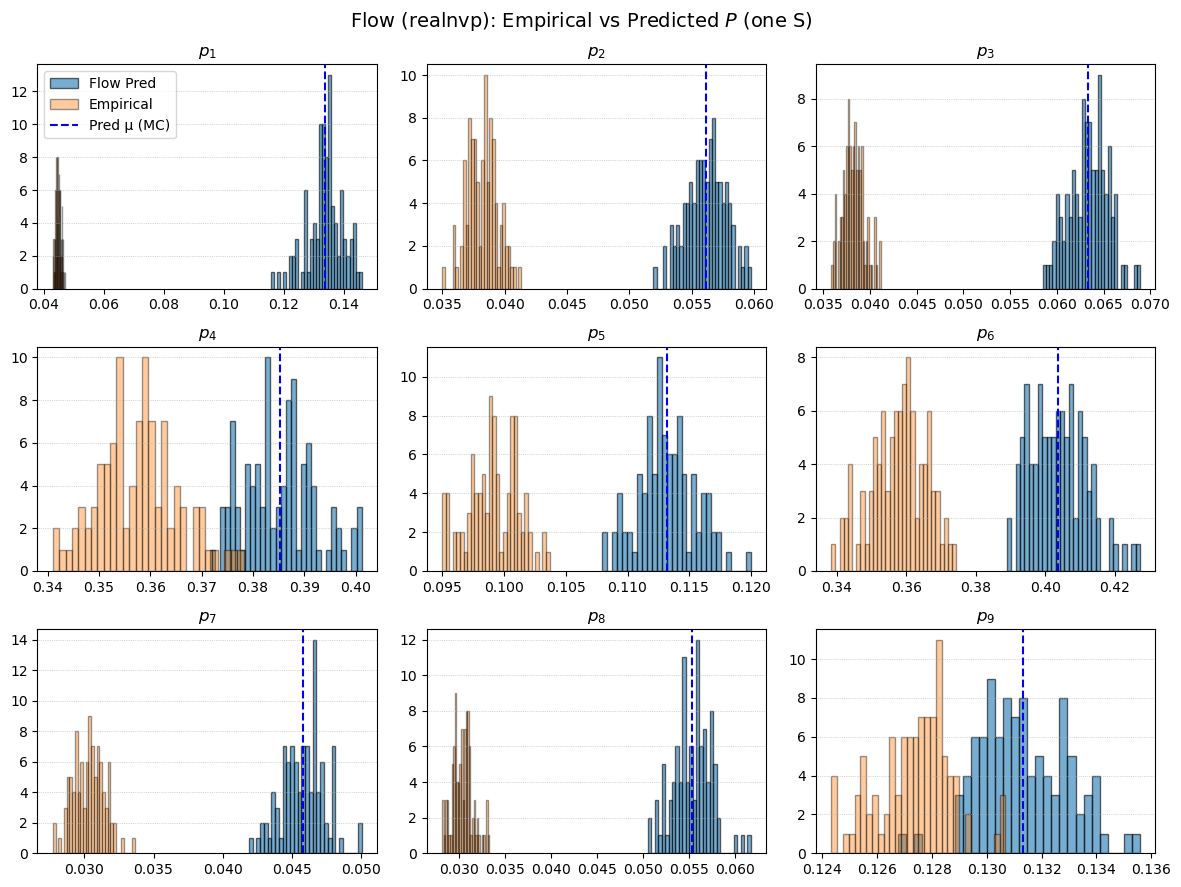

In [34]:
# === plots: histograms (pred vs empirical) per component ===
fig, axs = plt.subplots(3, 3, figsize=(12, 9))
axs = axs.flatten()

# compute MC estimates from the predicted samples
mu_mc  = P_hat_np.mean(axis=0)   # shape (P_DIM,)
std_mc = P_hat_np.std(axis=0)    # optional, for ±σ bands


for i in range(P_DIM):
    axs[i].hist(P_hat_np[:, i], bins=30, alpha=0.6, edgecolor='black', label='Flow Pred')
    axs[i].hist(P_true_samples[:, i], bins=30, alpha=0.4, edgecolor='black', label='Empirical')
    axs[i].axvline(mu_mc[i], color='blue', linestyle='--', label='Pred μ (MC)' if i == 0 else None)
    axs[i].set_title(f"$p_{{{i+1}}}$")
    axs[i].grid(True, axis='y', linestyle=':', linewidth=0.5)
    if i == 0: axs[i].legend()

plt.suptitle(f"Flow ({flow_type}): Empirical vs Predicted $P$ (one S)", fontsize=14)
plt.tight_layout()
plt.show()

### 7) Quick numeric summary table

In [35]:
# === quick numeric summary table (means, stds, coverage) ===
print(f"{'comp':<6}{'μ_emp':>10}{'μ_pred':>10}{'σ_emp':>10}{'σ_pred':>10}{'Δμ':>10}{'σ*/σ':>10}{'cov68%':>10}{'cov95%':>10}")
print("-"*86)

sum_abs_dmu = sum_ratio = sum_cov68 = sum_cov95 = 0.0
row_fmt = "{comp:<6}{mu_emp:>10.4f}{mu_pred:>10.4f}{sigma_emp:>10.4f}{sigma_pred:>10.4f}{dmu:>10.4f}{ratio:>10.2f}{cov68:>10.2%}{cov95:>10.2%}"

for i in range(P_DIM):
    emp = P_true_samples[:, i]
    mu_emp, std_emp = emp.mean(), emp.std(ddof=0)
    mu_pred = mu_hat_np[i]
    std_pred = sigma_hat_adj_np[i]

    cov68 = ((emp >= (mu_pred - std_pred)) & (emp <= (mu_pred + std_pred))).mean()
    cov95 = ((emp >= (mu_pred - 2*std_pred)) & (emp <= (mu_pred + 2*std_pred))).mean()

    dmu = mu_pred - mu_emp
    ratio = (std_pred / std_emp) if std_emp > 0 else float("nan")

    print(row_fmt.format(
        comp=i+1, mu_emp=mu_emp, mu_pred=mu_pred,
        sigma_emp=std_emp, sigma_pred=std_pred,
        dmu=dmu, ratio=ratio, cov68=cov68, cov95=cov95
    ))

    sum_abs_dmu += abs(dmu)
    sum_ratio   += ratio
    sum_cov68   += cov68
    sum_cov95   += cov95

n = P_DIM
empty10 = " " * 10
print("-"*86)
print(f"{'avg':<6}{empty10}{empty10}{empty10}{empty10}"
      f"{(sum_abs_dmu/n):>10.4f}{(sum_ratio/n):>10.2f}{(sum_cov68/n):>10.2%}{(sum_cov95/n):>10.2%}")

comp       μ_emp    μ_pred     σ_emp    σ_pred        Δμ      σ*/σ    cov68%    cov95%
--------------------------------------------------------------------------------------
1         0.0448    0.3919    0.0009    0.0024    0.3472      2.74     0.00%     0.00%
2         0.0382    0.1082    0.0012    0.0017    0.0700      1.38     0.00%     0.00%
3         0.0382    0.1361    0.0011    0.0012    0.0979      1.10     0.00%     0.00%
4         0.3577    0.4660    0.0077    0.0025    0.1083      0.33     0.00%     0.00%
5         0.0991    0.1502    0.0020    0.0014    0.0510      0.70     0.00%     0.00%
6         0.3577    0.5331    0.0079    0.0022    0.1754      0.27     0.00%     0.00%
7         0.0303    0.0902    0.0011    0.0011    0.0599      0.97     0.00%     0.00%
8         0.0304    0.1275    0.0011    0.0006    0.0971      0.55     0.00%     0.00%
9         0.1273    0.1416    0.0014    0.0011    0.0142      0.78     0.00%     0.00%
-------------------------------------------

### 8) (Optional) Evaluate many S’s at once (MAE/MSE on μ only)

In [36]:
# === evaluate many S’s at once ===
num_to_eval = min(40, len(S_keys))
sel_indices = np.linspace(0, len(S_keys)-1, num_to_eval, dtype=int)

rows = []
all_emp_for_T = []

MC_SAMPLES = 500

for sidx in sel_indices:
    S_arr = np.array(S_keys[sidx], float)
    emp_raw = empirical_data[S_keys[sidx]]
    n_emp = emp_raw.shape[0]

    # normalize S
    Sv = torch.tensor(S_arr, dtype=torch.float32, device=device).unsqueeze(0)
    Sn_v = norm_S(Sv)

    # conditioner μ/σ in RAW space (no sampling), then apply rho shrink
    with torch.no_grad():
        mu_theory_raw, sigma_theory_raw = get_mu_sigma_raw_for_S(model, Sn_v)
        mu_raw_t    = mu_theory_raw[0]
        sigma_raw_t = sigma_theory_raw[0]
        sigma_raw_t = adjust_sigma_by_rho(sigma_raw_t, Sv)

    mu_raw    = mu_raw_t.cpu().numpy()
    sigma_raw = sigma_raw_t.cpu().numpy()


    # empirical stats
    mu_emp  = emp_raw.mean(axis=0)
    std_emp = emp_raw.std(axis=0, ddof=0)
    std_emp = np.where(std_emp < 1e-12, 1e-12, std_emp)

    # metrics
    dmu          = mu_raw - mu_emp
    mae_mu       = float(np.mean(np.abs(dmu)))
    ratio_sigma  = float(np.mean(sigma_raw / std_emp))

    # coverage across all samples & dims for this S using ±σ (conditioner + rho-adjust)

    lo1, hi1 = mu_raw - sigma_raw,     mu_raw + sigma_raw
    lo2, hi2 = mu_raw - 2*sigma_raw,   mu_raw + 2*sigma_raw
    cov68 = float(np.mean((emp_raw >= lo1) & (emp_raw <= hi1)))
    cov95 = float(np.mean((emp_raw >= lo2) & (emp_raw <= hi2)))

    # # 🔁 (optional) quantile-based coverage (better for non-Gaussian)
    # q16, q84 = np.percentile(P_hat_raw, [16, 84], axis=0)
    # q2p5, q97p5 = np.percentile(P_hat_raw, [2.5, 97.5], axis=0)
    # cov68_q = float(np.mean((emp_raw >= q16) & (emp_raw <= q84)))
    # cov95_q = float(np.mean((emp_raw >= q2p5) & (emp_raw <= q97p5)))

    # exact flow NLL on empirical samples (same as before)
    P_emp_t = torch.tensor(emp_raw, dtype=torch.float32, device=device)
    Sn_rep  = Sn_v.repeat(P_emp_t.size(0), 1)
    with torch.no_grad():
        logp = flow_logprob_batch(model, Sn_rep, P_emp_t)
    nll = float((-logp).mean())

    rows.append({
        "S_idx": int(sidx),
        "n_emp": int(n_emp),
        "MAE_mu": mae_mu,
        "ratio_sigma": ratio_sigma,
        "cov68": cov68,
        "cov95": cov95,
        "NLL": nll,
        # "cov68_q": cov68_q, "cov95_q": cov95_q,  # enable if you add quantile coverage
    })

    # store MC triplets for global calibration T
    all_emp_for_T.append((emp_raw.copy(), mu_raw.copy(), sigma_raw.copy()))

df = pd.DataFrame(rows).sort_values("S_idx").reset_index(drop=True)
display_cols = ["S_idx","n_emp","MAE_mu","ratio_sigma","cov68","cov95","NLL"]  # add cov68_q/cov95_q if used
print("\n============ Per‑S summary (sorted by S_idx) ============")
print(df[display_cols].to_string(index=False, float_format=lambda x: f"{x:0.4f}"))

print("\n============ Global summary ============")
print(f"✅ Average over {len(sel_indices)} S: \n"
      f"    - MAE_mu = {df['MAE_mu'].mean():0.4f} \n"
      f"    - ratio_sigma = {df['ratio_sigma'].mean():0.2f} \n"
      f"    - cov68 = {df['cov68'].mean():0.2%} \n"
      f"    - cov95 = {df['cov95'].mean():0.2%} \n"
      f"    - NLL = {df['NLL'].mean():0.4f}")



============ Per‑S summary (sorted by S_idx) ============
 S_idx  n_emp  MAE_mu  ratio_sigma  cov68  cov95      NLL
     0    100  0.1009       0.3128 0.0000 0.0000 -27.0166
     1    100  0.1135       0.9816 0.0000 0.0000 -29.4571
     2    100  0.0272       0.2710 0.0000 0.0000 -12.4358
     3    100  0.1937       2.7205 0.0000 0.0000 -31.3944
     4    100  0.0583       0.5542 0.0011 0.0022 -29.5847
     5    100  0.0284       0.4251 0.0067 0.0156 -28.2218
     6    100  0.0945       0.8577 0.0000 0.0000 -30.2549
     7    100  0.4866       0.3002 0.0000 0.0000 -31.9338
     8    100  0.1169       0.8889 0.0000 0.0000 -29.3386
     9    100  0.1454       1.3265 0.0000 0.0000 -31.2135
    10    100  0.1305       1.0729 0.0000 0.0000 -29.9563
    11    100  0.2269       0.3502 0.0000 0.0000 -31.0998
    12    100  0.0614       0.8274 0.0511 0.1022 -28.3040
    13    100  0.5103       0.3221 0.0000 0.0000 -31.9112
    14    100  0.1970       3.1007 0.0000 0.0000 -31.9574
    15    100